<h6> the dataset is for 10128 unique customers <h6>

In [2]:
import os
import zipfile
import chardet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
#inspect contents of zipfile
with zipfile.ZipFile('Credit-Score-Data.zip', 'r') as zip_ref:
    print(zip_ref.namelist())


['Credit Score Data/', 'Credit Score Data/.DS_Store', '__MACOSX/Credit Score Data/._.DS_Store', 'Credit Score Data/train.csv', '__MACOSX/Credit Score Data/._train.csv']


In [4]:

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)  # Show all columns
#read in csv file
csv_file= 'Credit Score Data/train.csv'
zip_path = 'Credit-Score-Data.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open(csv_file) as file:
        df = pd.read_csv(file)
print(df.shape)
df.head(3)


(100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good


In [22]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [24]:
#check for duplicates
df.duplicated().sum()

0

In [5]:
#check for missing values and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

<h4>bivariate analysis(numerical)<h4>

In [52]:
#summary statistics
pd.options.display.float_format = '{:.2f}'.format
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100000.00,80631.50,43301.49,5634.00,43132.75,80631.50,118130.25,155629.00
Customer_ID,100000.00,25982.67,14340.54,1006.00,13664.50,25777.00,38385.00,50999.00
Month,100000.00,4.50,2.29,1.00,2.75,4.50,6.25,8.00
Age,100000.00,33.32,10.76,14.00,24.00,33.00,42.00,56.00
SSN,100000.00,500461680.26,290826734.39,81349.00,245168577.25,500688611.50,756002666.25,999993421.00
Annual_Income,100000.00,50505.12,38299.42,7005.93,19342.97,36999.71,71683.47,179987.28
Monthly_Inhand_Salary,100000.00,4197.27,3186.43,303.65,1626.59,3095.91,5957.72,15204.63
Num_Bank_Accounts,100000.00,5.37,2.59,0.00,3.00,5.00,7.00,11.00
Num_Credit_Card,100000.00,5.53,2.07,0.00,4.00,5.00,7.00,11.00
Interest_Rate,100000.00,14.53,8.74,1.00,7.00,13.00,20.00,34.00


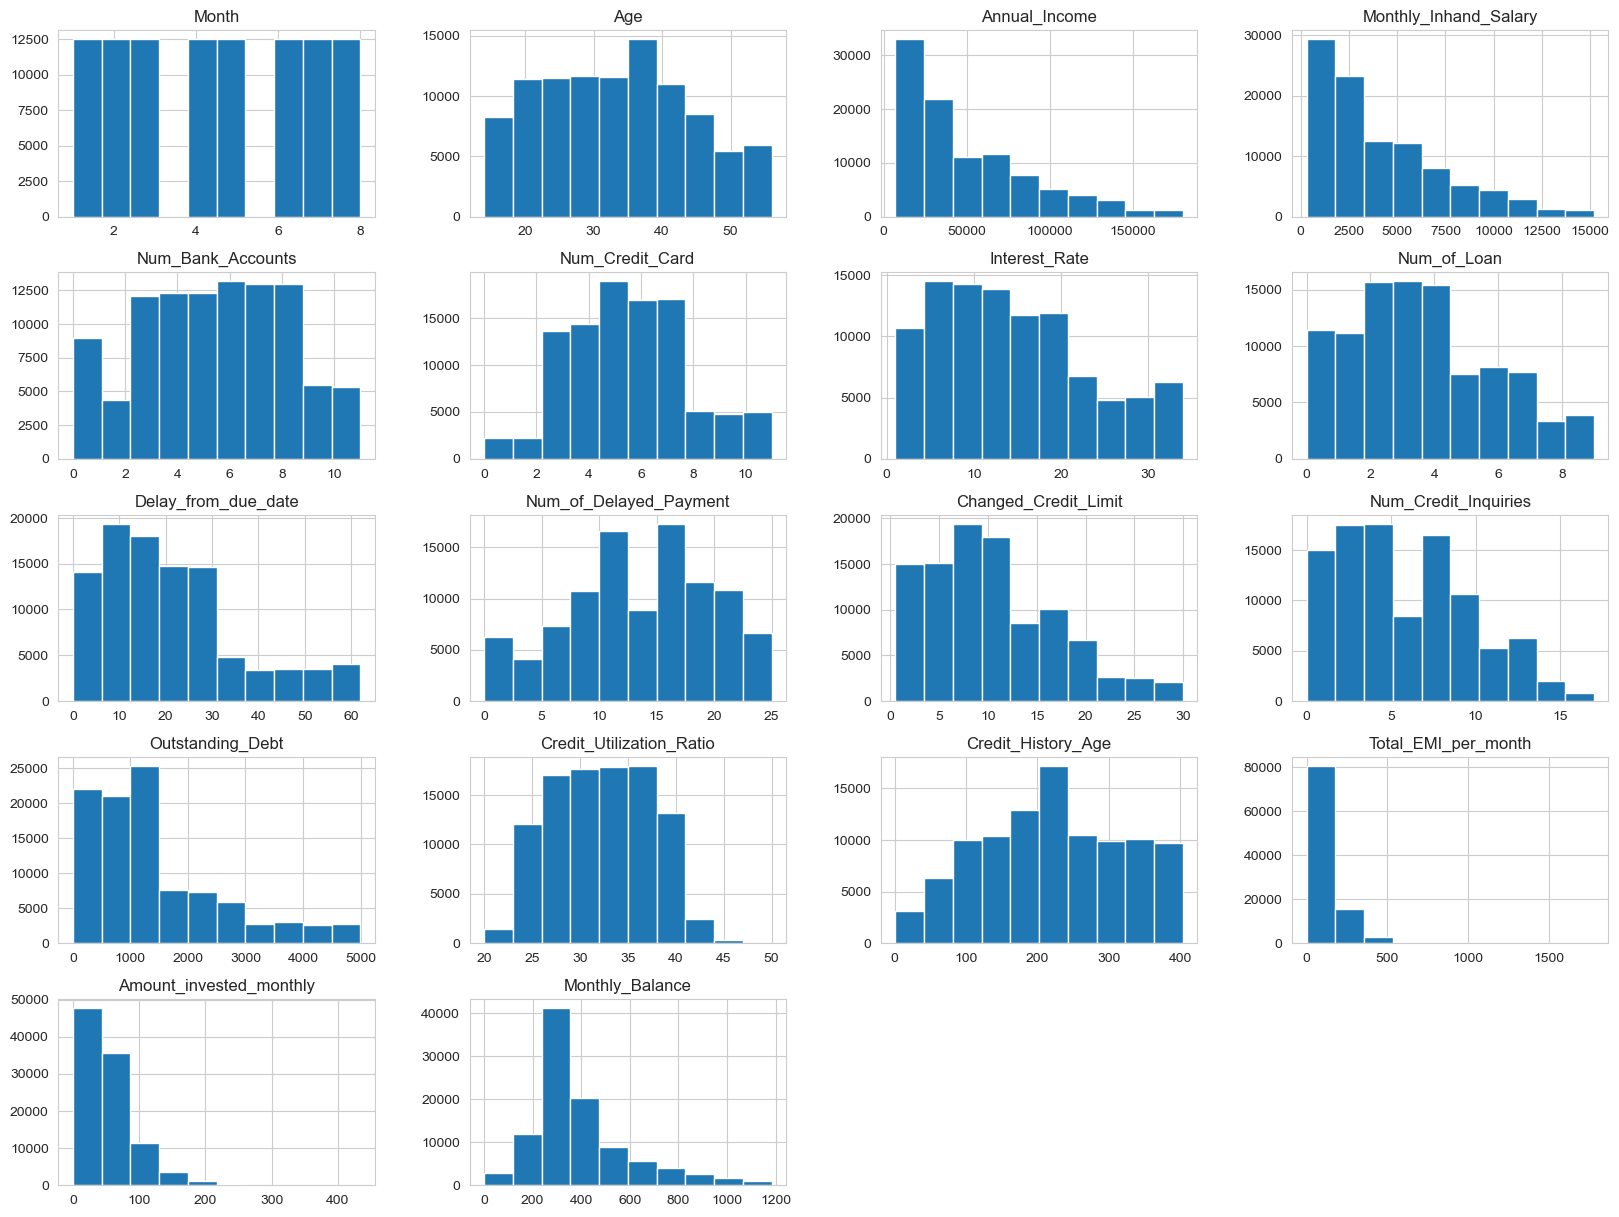

In [76]:
num_cols = df.select_dtypes(exclude ='object')
num_cols.drop(columns =['ID','Customer_ID','SSN'], inplace = True)
#histogram of all numerical columns
num_cols.hist(figsize =(20,15));

In [82]:
#skewness
num_cols.skew()

Month                       0.00
Age                         0.16
Annual_Income               1.13
Monthly_Inhand_Salary       1.13
Num_Bank_Accounts          -0.19
Num_Credit_Card             0.23
Interest_Rate               0.50
Num_of_Loan                 0.45
Delay_from_due_date         0.97
Num_of_Delayed_Payment     -0.21
Changed_Credit_Limit        0.71
Num_Credit_Inquiries        0.41
Outstanding_Debt            1.21
Credit_Utilization_Ratio    0.03
Credit_History_Age         -0.05
Total_EMI_per_month         4.04
Amount_invested_monthly     1.76
Monthly_Balance             1.36
dtype: float64

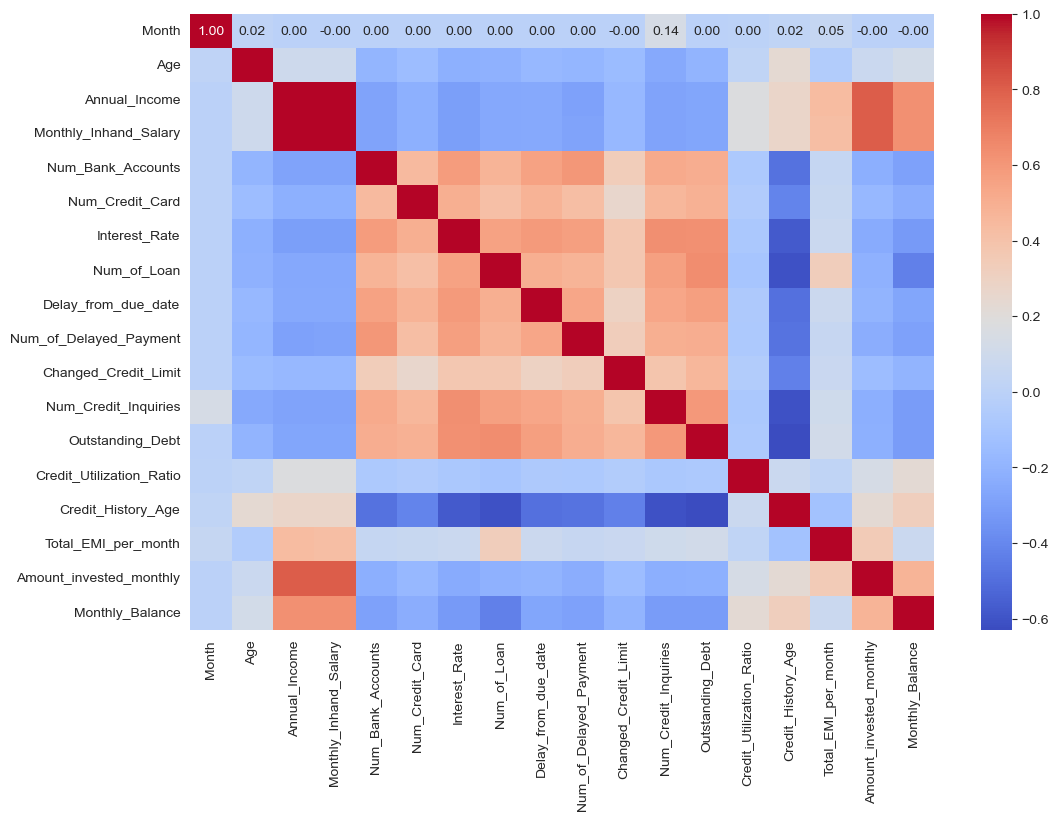

In [78]:
#correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

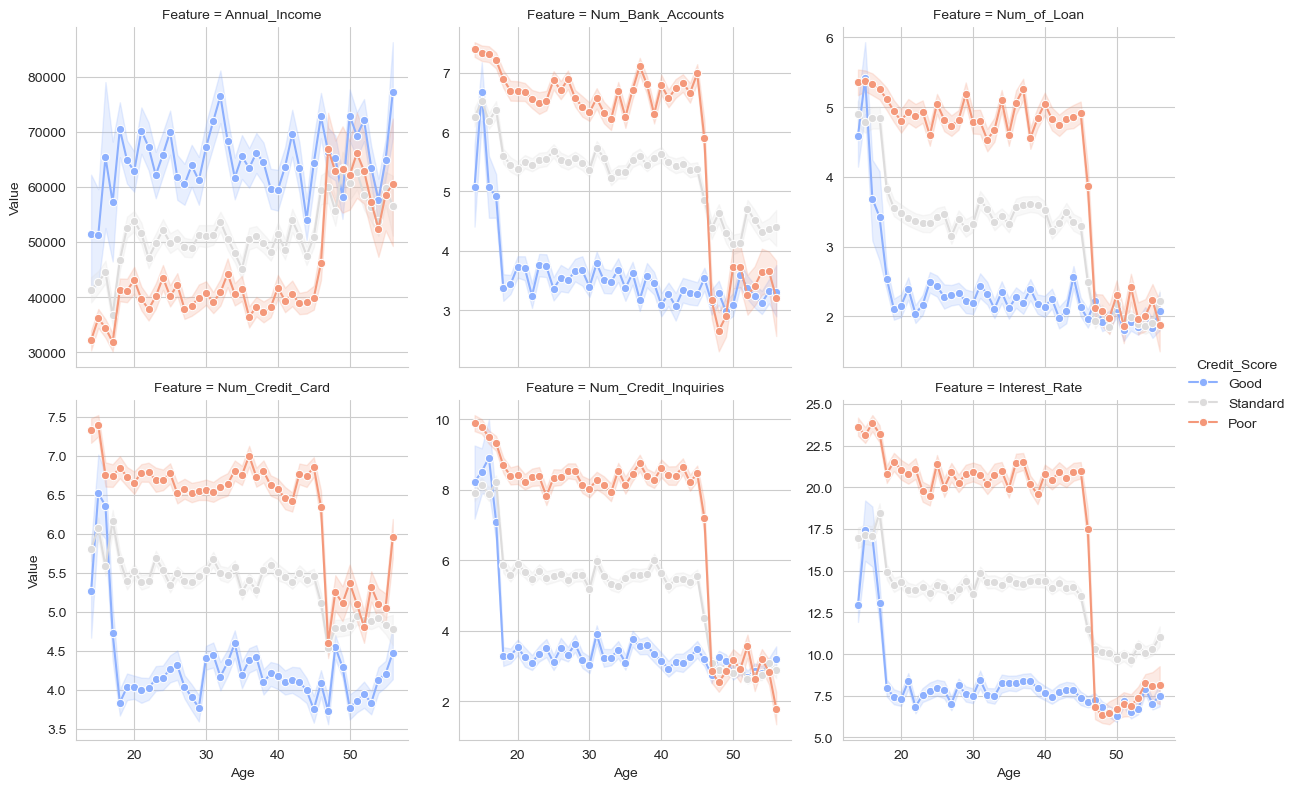

In [8]:
#relationship btn selected num variables across age and credit score
import warnings
# Suppress the specific warning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn._oldcore")

# Melt the DataFrame to long format
long_df = df.melt(id_vars=['Age', 'Credit_Score'], 
                     value_vars=['Annual_Income', 'Num_Bank_Accounts', 'Num_of_Loan', 
                                 'Num_Credit_Card', 'Num_Credit_Inquiries','Interest_Rate'],
                     var_name='Feature', value_name='Value')

# Set Seaborn style
sns.set_style("whitegrid")

# Create a FacetGrid with multiple line plots
g = sns.FacetGrid(long_df, col="Feature", hue="Credit_Score", palette="coolwarm", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "Age", "Value", marker="o")

# Adjust layout
g.add_legend()
plt.show()


<h5> as expected we see a high annual income results into a good credit score and older customers are earning more
 younger people tend to have more bank accounts than older ones,younger people make more inquiries as well as those with a poor credit score
keeping more than 4 accounts is not good for your credit score, have less than 5 credit cards, 
7.5% interest rate seems to be good for your credit score, maintain less than 3 loans at a time
<h5>

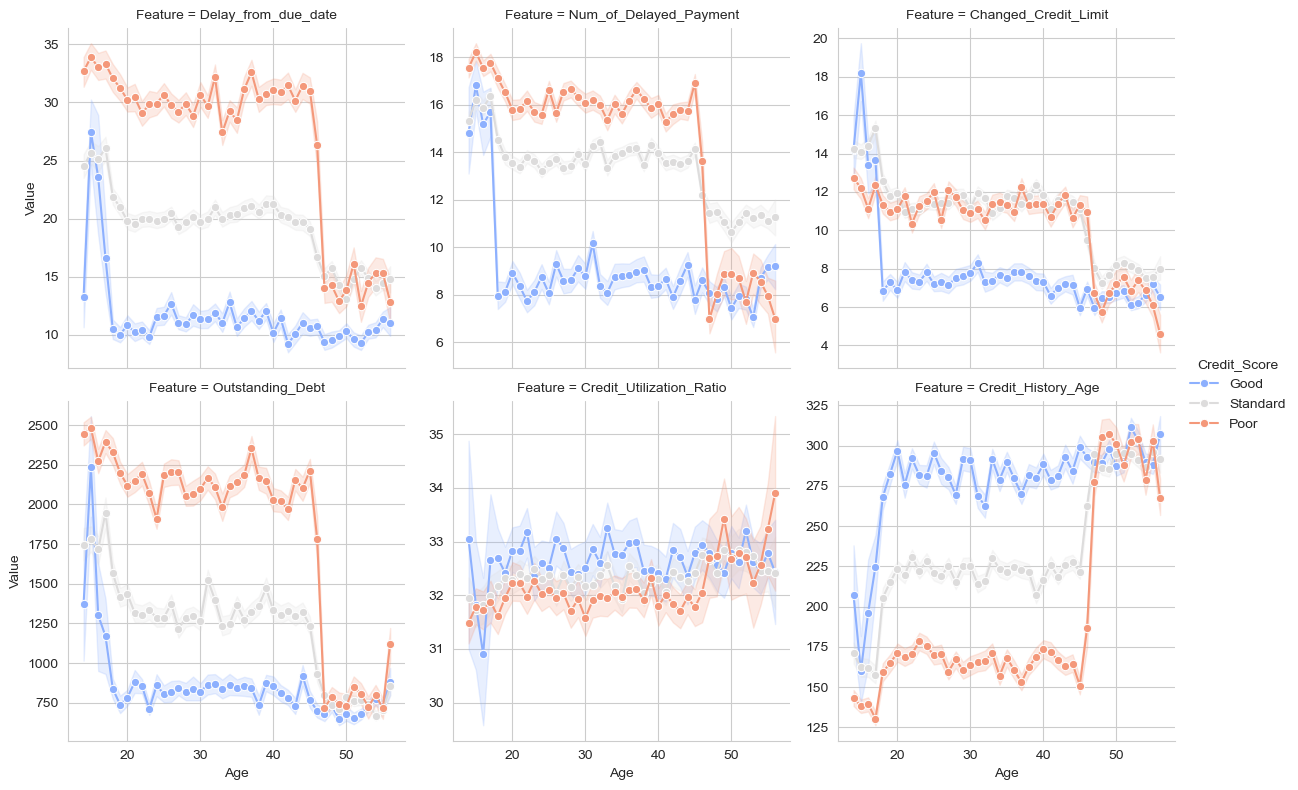

In [10]:
#relationship btn selected num variables across age and credit score
import warnings
# Suppress the specific warning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn._oldcore")

# Melt the DataFrame to long format
long_df = df.melt(id_vars=['Age', 'Credit_Score'], 
                     value_vars=['Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit',	'Outstanding_Debt',
                                 'Credit_Utilization_Ratio','Credit_History_Age'],
                     var_name='Feature', value_name='Value')

# Set Seaborn style
sns.set_style("whitegrid")

# Create a FacetGrid with multiple line plots
g = sns.FacetGrid(long_df, col="Feature", hue="Credit_Score", palette="coolwarm", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "Age", "Value", marker="o")

# Adjust layout
g.add_legend()
plt.show()


<h5>delaying payment less than 14 days is good for your score,below 10 delayed paymenst is good for your score,
outsanding debt of below 1000,as expected older people have a big credit_history_age and big credit_history_age results in a good score,
according to this data credit_utilization has less effect on your score<h5>

<h4>univariate analysis(categorical)<h4>

In [35]:
cat_columns = df.select_dtypes('object')
cat_columns.nunique()

Name                     10128
Occupation                  15
Type_of_Loan              6261
Credit_Mix                   3
Payment_of_Min_Amount        3
Payment_Behaviour            6
Credit_Score                 3
dtype: int64

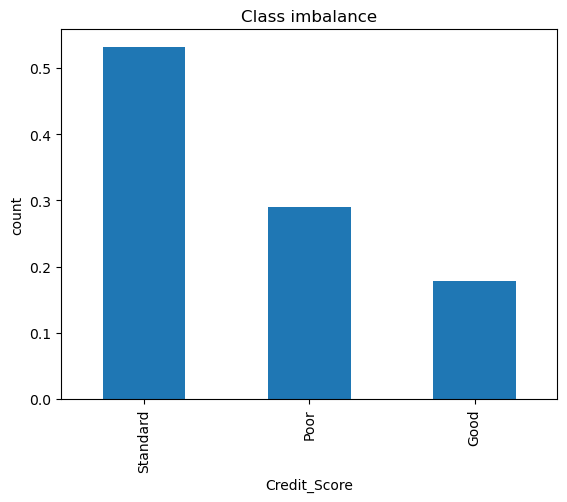

In [6]:
#check for class imbalance
df['Credit_Score'].value_counts(normalize = True).plot(kind ='bar',
                                                       ylabel ='count',
                                                      title ='Class imbalance');

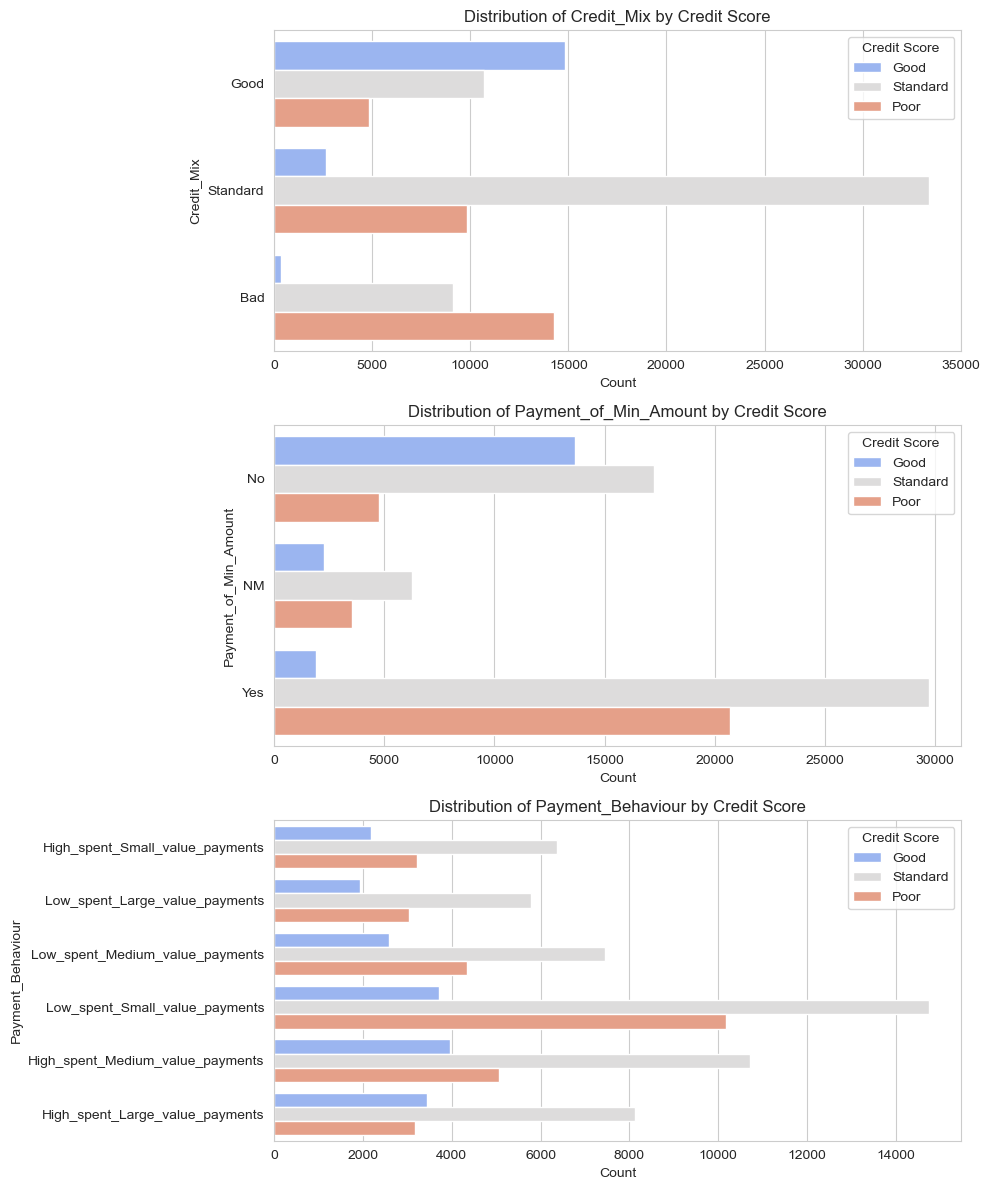

In [42]:
#plotting distribution of selected cat_columns by credit score
# Define categorical columns to plot
categorical_columns = ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

# Set up subplots
fig, axes = plt.subplots(nrows=len(categorical_columns), ncols=1, figsize=(10, 12))

# Loop through each categorical column and plot
for i, col in enumerate(categorical_columns):
    ax = axes[i]
    sns.countplot(y=df[col], hue=df['Credit_Score'], palette='coolwarm', ax=ax)
    ax.set_title(f"Distribution of {col} by Credit Score")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)
    ax.legend(title="Credit Score")

# Adjust layout
plt.tight_layout()
plt.show()


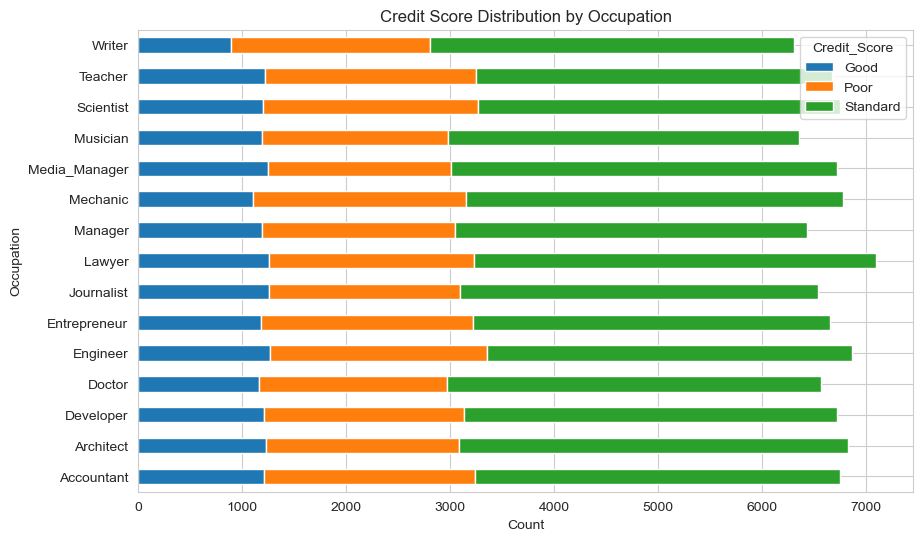

In [20]:
#credit score distribution by occupation
# Pivoting the data
pivot_table = pd.pivot_table(df, 
                             index='Occupation', 
                             columns='Credit_Score', 
                             aggfunc='size',  
                             fill_value=0) 

# Display the result
pivot_table.plot(kind ='barh',stacked=True, figsize=(10, 6))
plt.title('Credit Score Distribution by Occupation')
plt.ylabel('Occupation')
plt.xlabel('Count');

<h5>next step: model building<h5>

<h5>So we see that our  data is imbalanced, most features are positively skewed,and we have autocorrelation issues,
which means that we should steer clear of linear models, and try a tree-based model instead.<h5>